# Cost Structure Analysis: PyPSA-Earth Run A vs Run B

Audits every cost component actually used by the model, CAPEX, fixed O&M, variable OPEX,
fuel, and carbon, and shows how each maps onto PyPSA's cost attributes and PyPSA-Earth's
objective function (Parzen et al., 2023, Eq. A.1).

**Before running:** set `RUN_A_PATH` / `RUN_B_PATH`, and fill in `FUEL_PRICE`,
`OVERNIGHT_CAPEX`, `TECH_LIFETIME` in the config cell if you want the fuel/non-fuel and
CAPEX/FOM decompositions, both are optional, the notebook runs without them but skips those
specific breakdowns.


## 1. What Costs PyPSA-Earth Actually Includes

PyPSA-Earth's objective is to minimise total annualised system cost, formalised in Parzen et
al. (2023), Eq. A.1, as five cost terms:

| Term in the objective | What it represents | PyPSA attribute |
|---|---|---|
| $c_{i,r} \cdot G_{i,r}$ | Generator capacity investment | `generators.capital_cost` × `p_nom_opt` |
| $c_l \cdot F_l$ | Transmission line investment | `lines.capital_cost` × `s_nom_opt` |
| $c^{store}_{i,s} \cdot H^{store}_{i,s} + c^-_{i,s} H^-_{i,s} + c^+_{i,s} H^+_{i,s}$ | Storage energy, discharge & charge capacity investment | `stores.capital_cost` × `e_nom_opt`, `links.capital_cost` × `p_nom_opt` (charger/discharger) |
| $o_{i,r} \cdot g_{i,r,t} \cdot w_t$ | Generator variable cost (fuel + non-fuel VOM, combined) | `generators.marginal_cost` × dispatch |
| $o^+_{i,s} h^+_{i,s,t} + o^-_{i,s} h^-_{i,s,t}$, $o^{store}_{i,s} e_{i,s,t}$ | Storage charge/discharge and standing (energy-level) cost | `links.marginal_cost`, `stores.marginal_cost` |

Two things worth being precise about when you write this up in Chapter 6:

- **`capital_cost` is annualised**, by PyPSA convention it is €/MW (or €/MWh) per
  year, already combining overnight CAPEX and fixed O&M via an annuity factor, *if your cost
  config built it that way*. PyPSA does not enforce this, it is a modelling convention you
  (or PyPSA-Earth's default `technology-data` cost sourcing) chose when the input `costs.csv`
  was assembled. Section 5 below tries to back out the implied FOM component, but only if you
  supply the overnight CAPEX and lifetime it was annuitised from.
- **Carbon is not a cost term in the objective by default.** Parzen et al. list a
  "greenhouse gas emissions reduction constraint" as one of the model's five constraint
  categories, i.e. PyPSA-Earth's standard formulation caps emissions rather than pricing
  them. A carbon price only enters the objective if you explicitly added it to
  `marginal_cost`, or if you're reading it off the shadow price (`mu`) of a binding CO2
  `GlobalConstraint`, which is an output of the optimisation, not an input cost. Section 6
  checks for both cases in your solved networks.

**On totals:** any snapshot weighting (e.g. representative-day clustering) or multi-period
investment weighting changes how individual asset costs sum to the total system cost.
Reimplementing that weighting by hand is easy to get subtly wrong, so from Section 3 onward
this notebook uses PyPSA's built-in `n.statistics` accessor for every *total*, which handles
snapshot and investment-period weighting internally and is guaranteed to reconcile with
`n.objective`. The manual per-asset tables are kept alongside it, but only for inspecting raw
input values (`capital_cost`, `marginal_cost` as configured), not for totals.

## 0. Setup & Configuration

In [17]:
import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

PALETTE = {
    "blue_teal": "#0B4F6C", "amber": "#E8A33D", "slate": "#4A6572",
    "burgundy": "#7A3B46", "green": "#4B7A63", "teal_light": "#7FB3B3",
}
# Keyed to the carriers actually present in these networks (checked via n.generators.carrier /
# n.stores.carrier / n.storage_units.carrier): solar, onwind, CCGT, coal, oil, battery, hydro.
# Only 6 palette colors for 7 carriers, so coal and oil currently share "burgundy" — swap one if
# you want them visually distinct.
CARRIER_COLORS = {
    "solar": PALETTE["amber"], "onwind": PALETTE["green"], "CCGT": PALETTE["slate"],
    "coal": PALETTE["burgundy"], "oil": PALETTE["burgundy"], "battery": PALETTE["blue_teal"],
    "hydro": PALETTE["teal_light"],
}
def color_for(carrier):
    return CARRIER_COLORS.get(carrier, "#999999")

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "font.size": 12, "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "figure.autolayout": True,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")

def stat_total(stats_result):
    '''n.statistics.*() returns a Series for single-period networks, a DataFrame indexed by
    period for multi-period ones. Always return a (component, carrier)-indexed Series summed
    across periods, so downstream code doesn't need to branch on network type.'''
    if isinstance(stats_result, pd.DataFrame):
        return stats_result.sum(axis=1)
    return stats_result


In [18]:
RUN_A_PATH = r"results/baseline_no_bess_2050_overnight/networks/elec_s_24_ec_lv1.0_1h.nc"
RUN_B_PATH = r"results/baseline_bess_2050_overnight/networks/elec_s_24_ec_lv1.0_1h.nc"

CARBON_PRICE = 0   # € / tCO2, for the hypothetical decomposition in Section 6

CO2_FACTORS = {  # tCO2 per MWh, matched to this fleet's actual carriers (oil, CCGT, coal)
    "oil": 0.75, "CCGT": 0.40, "coal": None,  # TODO: coal wasn't in the original fleet assumptions, add a sourced value
}

# --- Optional: fill in to unlock the fuel vs non-fuel VOM decomposition in Section 4 ---
FUEL_PRICE = {  # € / MWh fuel input, None = skip this carrier
    "oil": None, "CCGT": None, "coal": None,
}

# --- Optional: fill in to unlock the CAPEX vs FOM back-out in Section 5 ---
# overnight CAPEX in €/MW, lifetime in years, per carrier
OVERNIGHT_CAPEX = {"solar": None, "onwind": None, "oil": None, "CCGT": None, "coal": None, "battery": None}
TECH_LIFETIME = {"solar": None, "onwind": None, "oil": None, "CCGT": None, "coal": None, "battery": None}
FOM_DISCOUNT_RATE = 0.06  # rate used to annuitise CAPEX, should match your Ch. 5 SOC rate

def crf(rate, lifetime):
    '''Capital recovery factor, converts an overnight cost into an annuity.'''
    if rate == 0:
        return 1 / lifetime
    return rate / (1 - (1 + rate) ** (-lifetime))


## 2. Load Networks

In [19]:

n_a = pypsa.Network(RUN_A_PATH)
n_b = pypsa.Network(RUN_B_PATH)
print("Run A components:", n_a.generators.shape[0], "generators,", n_a.stores.shape[0], "stores,",
      n_a.links.shape[0], "links,", n_a.lines.shape[0], "lines")
print("Run B components:", n_b.generators.shape[0], "generators,", n_b.stores.shape[0], "stores,",
      n_b.links.shape[0], "links,", n_b.lines.shape[0], "lines")


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Run A components: 81 generators, 0 stores, 0 links, 31 lines
Run B components: 105 generators, 24 stores, 48 links, 31 lines


## 3. CAPEX Audit

Annualised capital cost by technology, for both existing/committed (fixed) and candidate
(extendable) capacity, and the resulting total annualised investment cost per run.

Run B CAPEX audit:
      component                            name carrier  capacity_MW_or_MWh  \
0    Generator                    SN0 0 onwind  onwind            0.011096   
1    Generator                     SN0 0 solar   solar         2108.161874   
2    Generator                       SN0 1 oil     oil           15.360057   
3    Generator                    SN0 1 onwind  onwind            0.000735   
4    Generator                     SN0 1 solar   solar            0.014231   
..         ...                             ...     ...                 ...   
203       Line   lines new SN0 0 <-> SN0 19 AC      AC           14.402504   
204       Line  lines new SN0 18 <-> SN0 21 AC      AC           39.737295   
205       Line  lines new SN0 16 <-> SN0 21 AC      AC           50.393573   
206       Line   lines new SN0 13 <-> SN0 7 AC      AC           50.092517   
207       Line   lines new SN0 10 <-> SN0 5 AC      AC           99.310483   

     capital_cost_EUR_per_unit_per_year  \


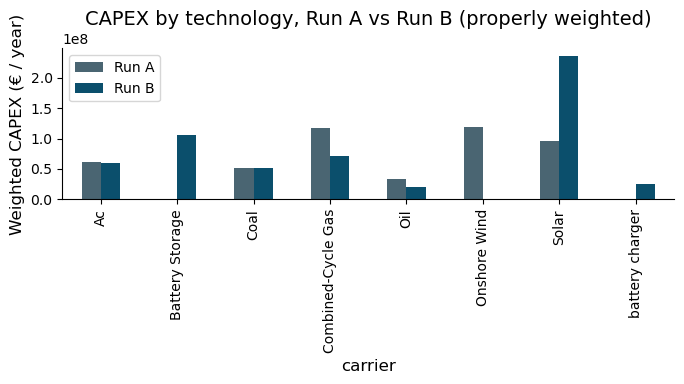

In [20]:

def capex_audit(n):
    rows = []
    for comp_name, df, cap_col, ext_col in [
        ("Generator", n.generators, "p_nom", "p_nom_extendable"),
        ("Store", n.stores, "e_nom", "e_nom_extendable"),
        ("Link", n.links, "p_nom", "p_nom_extendable"),
        ("Line", n.lines, "s_nom", "s_nom_extendable"),
    ]:
        if len(df) == 0:
            continue
        opt_col = cap_col + "_opt"
        capacity = df[opt_col].where(df[ext_col], df[cap_col])
        annualised_cost = capacity * df["capital_cost"]
        carrier = df["carrier"] if "carrier" in df.columns else pd.Series("n/a", index=df.index)
        for name in df.index:
            rows.append({
                "component": comp_name, "name": name, "carrier": carrier.get(name, "n/a"),
                "capacity_MW_or_MWh": capacity[name],  # MW for Generator/Line/Link, MWh for Store
                "capital_cost_EUR_per_unit_per_year": df.loc[name, "capital_cost"],
                "annualised_investment_cost_EUR_per_year": annualised_cost[name],
                "status": "candidate" if df.loc[name, ext_col] else "existing/committed",
            })
    return pd.DataFrame(rows)

capex_a = capex_audit(n_a)
capex_b = capex_audit(n_b)
print("Run B CAPEX audit:\n", capex_b)
capex_b.to_csv(FIG_DIR / "capex_audit_run_b.csv", index=False)

capex_by_carrier = pd.DataFrame({
    "Run A": capex_a.groupby("carrier")["annualised_investment_cost_EUR_per_year"].sum(),
    "Run B": capex_b.groupby("carrier")["annualised_investment_cost_EUR_per_year"].sum(),
}).fillna(0)
print("\nRaw (unweighted) annualised investment cost by carrier, in EUR/year, for input inspection only:\n", capex_by_carrier)

# --- Properly-weighted totals, use these for any figure or number you report ---
capex_stats_a = stat_total(n_a.statistics.capex())
capex_stats_b = stat_total(n_b.statistics.capex())
print("\nWeighted CAPEX by component & carrier (Run B, EUR/year, from n.statistics):\n", capex_stats_b)

capex_stats_total = pd.DataFrame({"Run A": capex_stats_a, "Run B": capex_stats_b}).fillna(0)

fig, ax = plt.subplots(figsize=(7, 4))
capex_stats_total.groupby(level="carrier").sum().plot(
    kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("Weighted CAPEX (€ / year)")
ax.set_title("CAPEX by technology, Run A vs Run B (properly weighted)")
savefig(fig, "capex_by_technology")
plt.show()


## 4. Variable OPEX Audit

`marginal_cost` as stored in the network is fuel and non-fuel variable O&M **already
combined**, PyPSA does not track them separately. The fuel/non-fuel split below only runs for
carriers where you've filled in `FUEL_PRICE` and the generator has an `efficiency` set, since
`implied VOM = marginal_cost - fuel_price / efficiency`.

In [21]:

def opex_audit(n):
    g = n.generators.copy()
    dispatch_total = n.generators_t.p.sum()
    df = pd.DataFrame({
        "carrier": g.carrier,
        "marginal_cost_EUR_per_MWh": g.marginal_cost,
        "efficiency_per_unit": g.efficiency,
        "dispatch_MWh_per_year": dispatch_total,
    })
    df["variable_cost_EUR_per_year"] = df["marginal_cost_EUR_per_MWh"] * df["dispatch_MWh_per_year"]
    return df

opex_a = opex_audit(n_a)
opex_b = opex_audit(n_b)
print("Run B variable OPEX audit:\n", opex_b)
opex_b.to_csv(FIG_DIR / "opex_audit_run_b.csv")

opex_by_carrier = pd.DataFrame({
    "Run A": opex_a.groupby("carrier")["variable_cost_EUR_per_year"].sum(),
    "Run B": opex_b.groupby("carrier")["variable_cost_EUR_per_year"].sum(),
}).fillna(0)
print("\nRaw (unweighted) variable cost by carrier, in EUR/year, for input inspection only:\n", opex_by_carrier)

# --- Properly-weighted totals ---
opex_stats_a = stat_total(n_a.statistics.opex())
opex_stats_b = stat_total(n_b.statistics.opex())
opex_stats_total = pd.DataFrame({"Run A": opex_stats_a, "Run B": opex_stats_b}).fillna(0)
print("\nWeighted variable OPEX by component & carrier, in EUR/year (from n.statistics):\n", opex_stats_total)

# --- fuel vs non-fuel VOM decomposition, only where FUEL_PRICE is known ---
decomposed = []
for carrier, fuel_price in FUEL_PRICE.items():
    if fuel_price is None:
        continue
    rows = opex_b[opex_b.carrier == carrier]
    for name, row in rows.iterrows():
        if pd.isna(row.efficiency_per_unit) or row.efficiency_per_unit == 0:
            continue
        fuel_component = fuel_price / row.efficiency_per_unit
        vom_component = row.marginal_cost_EUR_per_MWh - fuel_component
        decomposed.append({"name": name, "carrier": carrier,
                            "fuel_cost_EUR_per_MWh": fuel_component, "vom_EUR_per_MWh": vom_component})
if decomposed:
    decomposed_df = pd.DataFrame(decomposed)
    print("\nFuel vs non-fuel VOM decomposition (Run B), EUR/MWh:\n", decomposed_df)
    if (decomposed_df["vom_EUR_per_MWh"] < 0).any():
        print("WARNING: implied non-fuel VOM is negative for some generators, FUEL_PRICE or "
              "efficiency assumptions don't match what's actually in marginal_cost, check your inputs.")
else:
    print("\nNo FUEL_PRICE values set, skipping fuel/non-fuel decomposition.")


Run B variable OPEX audit:
                                    carrier  marginal_cost_EUR_per_MWh  \
Generator                                                               
SN0 0 battery load shedding  load shedding               1.000000e+06   
SN0 0 load shedding          load shedding               1.000000e+06   
SN0 0 onwind                        onwind               2.492008e-02   
SN0 0 solar                          solar               2.079263e-02   
SN0 1 battery load shedding  load shedding               1.000000e+06   
...                                    ...                        ...   
SN0 9 CCGT                            CCGT               4.518917e+01   
SN0 9 battery load shedding  load shedding               1.000000e+06   
SN0 9 load shedding          load shedding               1.000000e+06   
SN0 9 onwind                        onwind               2.424658e-02   
SN0 9 solar                          solar               2.062876e-02   

                      

## 5. Fixed O&M (Back-Out Check)

Not a standard PyPSA attribute. If `capital_cost` in your network already combines annuitised
overnight CAPEX and FOM (the usual PyPSA-Earth/technology-data convention), this cell backs
out the implied FOM per technology, **only where you've filled in `OVERNIGHT_CAPEX` and
`TECH_LIFETIME`** in the config cell, so you can sanity-check what's actually embedded in your
`capital_cost` values against your Chapter 6 source data.

In [22]:

rows = []
for carrier, overnight in OVERNIGHT_CAPEX.items():
    lifetime = TECH_LIFETIME.get(carrier)
    if overnight is None or lifetime is None:
        continue
    matching = n_b.generators[n_b.generators.carrier == carrier]
    if matching.empty:
        matching = pd.concat([
            n_b.stores[n_b.stores.carrier == carrier].rename(columns={"e_nom_extendable": "p_nom_extendable"}),
        ]) if carrier in n_b.stores.carrier.values else matching
    for name, row in matching.iterrows():
        annuitised_capex = overnight * crf(FOM_DISCOUNT_RATE, lifetime)
        implied_fom = row.capital_cost - annuitised_capex
        rows.append({"name": name, "carrier": carrier,
                     "capital_cost_in_model_EUR_per_year": row.capital_cost,
                     "annuitised_overnight_capex_EUR_per_year": annuitised_capex,
                     "implied_fom_EUR_per_year": implied_fom})

if rows:
    fom_df = pd.DataFrame(rows)
    print(fom_df)
    if (fom_df["implied_fom_EUR_per_year"] < 0).any():
        print("WARNING: implied FOM is negative, your OVERNIGHT_CAPEX/TECH_LIFETIME/FOM_DISCOUNT_RATE "
              "assumptions don't reconcile with the capital_cost actually in the network.")
else:
    print("OVERNIGHT_CAPEX / TECH_LIFETIME not filled in, skipping FOM back-out.")


OVERNIGHT_CAPEX / TECH_LIFETIME not filled in, skipping FOM back-out.


## 6. Carbon Cost

Two distinct things, don't conflate them: (a) the model's own endogenous carbon shadow
price, if you enforced an emissions cap via a `GlobalConstraint`, that's an optimisation
*output*; (b) a hypothetical carbon cost at `CARBON_PRICE`, applied after the fact for
decomposition/sensitivity purposes, that's an *assumption* you're layering on, not something
the reference-case runs already account for unless you added it to `marginal_cost` yourself.

In [23]:

for label, n in [("Run A", n_a), ("Run B", n_b)]:
    co2_constraints = n.global_constraints[n.global_constraints.type == "primary_energy"] \
        if len(n.global_constraints) else n.global_constraints
    if len(co2_constraints):
        print(f"{label}: CO2 constraint(s) found:")
        print(co2_constraints[["sense", "constant", "mu"]])
        print("For a binding '<=' constraint, -mu is the model's implied cost per unit of "
              "relaxing the cap, i.e. its endogenous shadow price of carbon. Check the sign "
              "against your solver's convention before quoting it.")
    else:
        print(f"{label}: no CO2 GlobalConstraint found, emissions are not capped in this run, "
              "and no endogenous carbon shadow price is available.")


Run A: no CO2 GlobalConstraint found, emissions are not capped in this run, and no endogenous carbon shadow price is available.
Run B: no CO2 GlobalConstraint found, emissions are not capped in this run, and no endogenous carbon shadow price is available.


In [24]:
def emissions_by_carrier(n, factors=CO2_FACTORS):
    g = n.generators
    rows = {}
    for carrier, factor in factors.items():
        if factor is None:
            continue
        names = g.index[g.carrier == carrier]
        if len(names) == 0:
            continue
        rows[carrier] = n.generators_t.p[names].sum().sum() * factor  # tCO2/year
    return pd.Series(rows)

em_a = emissions_by_carrier(n_a)
em_b = emissions_by_carrier(n_b)
hypothetical_carbon_cost = pd.DataFrame({
    "Run A (EUR/year)": em_a * CARBON_PRICE, "Run B (EUR/year)": em_b * CARBON_PRICE,
}).fillna(0)
print(f"Hypothetical carbon cost at €{CARBON_PRICE}/tCO2 (not in the objective unless you added it), in EUR/year:")
print(hypothetical_carbon_cost)
if CARBON_PRICE == 0:
    print("\nCARBON_PRICE is 0, set it in the config cell to see this decomposition populated.")


Hypothetical carbon cost at €0/tCO2 (not in the objective unless you added it), in EUR/year:
      Run A (EUR/year)  Run B (EUR/year)
oil                0.0               0.0
CCGT               0.0               0.0

CARBON_PRICE is 0, set it in the config cell to see this decomposition populated.


saved figures/emissions_by_carrier.png


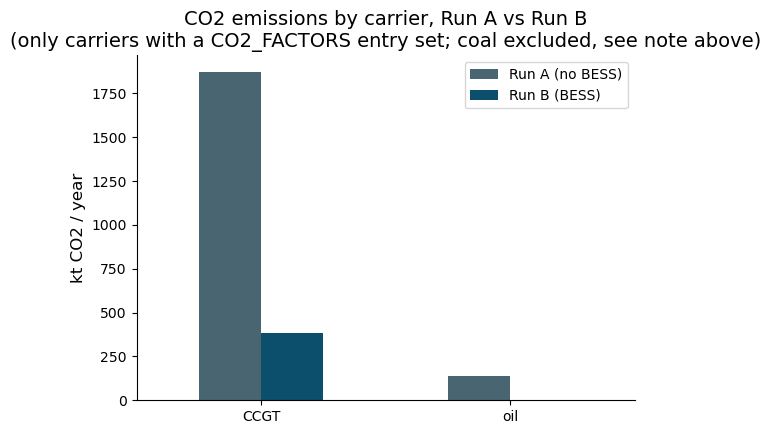

Total (of tracked carriers): Run A = 2,012 kt/yr, Run B = 383 kt/yr (81% lower with BESS)


In [25]:
em_carriers = sorted(set(em_a.index) | set(em_b.index))
em_df_kt = pd.DataFrame({
    "Run A (no BESS)": (em_a.reindex(em_carriers, fill_value=0)) / 1e3,
    "Run B (BESS)": (em_b.reindex(em_carriers, fill_value=0)) / 1e3,
})
fig, ax = plt.subplots(figsize=(6, 4.5))
em_df_kt.plot(kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("kt CO2 / year")
ax.set_title("CO2 emissions by carrier, Run A vs Run B\n(only carriers with a CO2_FACTORS entry set; coal excluded, see note above)")
plt.setp(ax.get_xticklabels(), rotation=0)
savefig(fig, "emissions_by_carrier")
plt.show()
print(f"Total (of tracked carriers): Run A = {em_a.sum()/1e3:,.0f} kt/yr, Run B = {em_b.sum()/1e3:,.0f} kt/yr "
      f"({100*(1 - em_b.sum()/em_a.sum()):.0f}% lower with BESS)")


## 7. System Cost Decomposition: CAPEX vs Variable OPEX vs Storage

Built from `n.statistics`, which correctly handles snapshot and investment-period weighting
(unlike a hand-rolled sum of `capacity × capital_cost`, which silently drops it) — but it does
**not** reconcile directly with `n.objective`, and that's not a bug to fix, it's how PyPSA's
LP formulation works:

- **`n.objective` omits a "baseline capacity" constant.** For every *extendable* asset, PyPSA
  subtracts `capital_cost × p_nom` (pre-existing capacity) out of the reported objective into
  `n.objective_constant`, and only the `capital_cost × p_nom_opt` decision term remains in
  `n.objective`. The true LP-priced total is `n.objective + n.objective_constant`.
- **Non-extendable assets' capital cost never enters the LP at all**, not even as a constant —
  see `define_objective()` in `pypsa/optimization/optimize.py`: both the investment term and
  the constant-subtraction loop are restricted to `n.get_extendable_i(c)`. If `p_nom_extendable
  = False` (e.g. your 4 custom BESS `StorageUnit`s, and most transmission lines in this
  network), its capital cost can't affect the optimal decision, so the solver just never adds
  it, anywhere. `n.statistics.capex()` still reports it, correctly, as part of the system's
  real cost.

So there are two legitimately different totals below: **full system cost** (every asset,
what you want for thesis reporting) and **LP-priced total** (only what the solver optimized
over, which is what actually reconciles with `n.objective + n.objective_constant`).

Run A decomposition by component (full system cost, all assets, EUR/year):
              capex_EUR_per_year  opex_EUR_per_year
component                                         
Generator          4.173221e+08       2.738972e+08
Line               6.146686e+07       0.000000e+00
StorageUnit        0.000000e+00       1.112300e+04
Run A: full system cost = €752,697,283/year  (includes €58,030,138/year of non-extendable/committed capacity, excluded from the LP objective)
Run A: LP-priced total  = €694,667,144/year  |  n.objective + n.objective_constant = €694,667,144/year

Run B decomposition by component (full system cost, all assets, EUR/year):
              capex_EUR_per_year  opex_EUR_per_year
component                                         
Generator          3.801532e+08       7.641903e+07
Line               5.956741e+07       0.000000e+00
Link               2.526381e+07       1.040326e+05
StorageUnit        5.435750e+06       1.379481e+04
Store              1.000506e+08       0.0

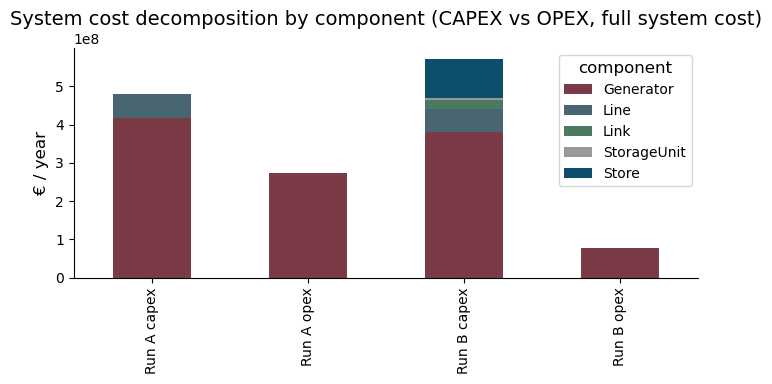

In [26]:
def cost_decomposition(n):
    capex_by_asset = stat_total(n.statistics.capex())  # ALL assets, extendable or not, EUR/year
    opex_by_asset = stat_total(n.statistics.opex())  # EUR/year
    combined = pd.DataFrame({"capex_EUR_per_year": capex_by_asset, "opex_EUR_per_year": opex_by_asset}).fillna(0)
    by_component = combined.groupby(level="component").sum()

    # Split capex into what PyPSA's LP objective actually prices (extendable assets only)
    # vs. non-extendable ("committed") capacity, which n.statistics reports but the objective
    # never includes at all -- see the markdown note above.
    extendable_capex = 0.0
    committed_capex = 0.0
    for comp_name, df, cap_col, ext_col in [
        ("Generator", n.generators, "p_nom", "p_nom_extendable"),
        ("Store", n.stores, "e_nom", "e_nom_extendable"),
        ("Link", n.links, "p_nom", "p_nom_extendable"),
        ("Line", n.lines, "s_nom", "s_nom_extendable"),
        ("StorageUnit", n.storage_units, "p_nom", "p_nom_extendable"),
    ]:
        if len(df) == 0:
            continue
        capacity = df[cap_col + "_opt"].where(df[ext_col], df[cap_col])
        cost = capacity * df["capital_cost"]
        extendable_capex += cost[df[ext_col]].sum()
        committed_capex += cost[~df[ext_col]].sum()

    full_system_cost = capex_by_asset.sum() + opex_by_asset.sum()  # EUR/year
    lp_priced_total = extendable_capex + opex_by_asset.sum()  # EUR/year
    true_objective = n.objective + n.objective_constant  # EUR/year
    return by_component, full_system_cost, lp_priced_total, true_objective, committed_capex

decomp_a, total_a, lp_total_a, true_obj_a, committed_a = cost_decomposition(n_a)
decomp_b, total_b, lp_total_b, true_obj_b, committed_b = cost_decomposition(n_b)

print("Run A decomposition by component (full system cost, all assets, EUR/year):\n", decomp_a)
print(f"Run A: full system cost = €{total_a:,.0f}/year  "
      f"(includes €{committed_a:,.0f}/year of non-extendable/committed capacity, excluded from the LP objective)")
print(f"Run A: LP-priced total  = €{lp_total_a:,.0f}/year  |  n.objective + n.objective_constant = €{true_obj_a:,.0f}/year")

print("\nRun B decomposition by component (full system cost, all assets, EUR/year):\n", decomp_b)
print(f"Run B: full system cost = €{total_b:,.0f}/year  "
      f"(includes €{committed_b:,.0f}/year of non-extendable/committed capacity, excluded from the LP objective)")
print(f"Run B: LP-priced total  = €{lp_total_b:,.0f}/year  |  n.objective + n.objective_constant = €{true_obj_b:,.0f}/year")

assert abs(lp_total_a - true_obj_a) < 1e-2 * abs(true_obj_a), "Run A LP-priced total does not reconcile with n.objective + n.objective_constant, investigate before reporting."
assert abs(lp_total_b - true_obj_b) < 1e-2 * abs(true_obj_b), "Run B LP-priced total does not reconcile with n.objective + n.objective_constant, investigate before reporting."
print("\nBoth runs' LP-priced totals (extendable capex + opex) reconcile with n.objective + n.objective_constant to within rounding.")
print("Use 'full system cost' for thesis reporting; 'LP-priced total' only if you specifically want")
print("the solver's internal decision-relevant cost (excludes committed/non-extendable capacity entirely).")

decomp_wide = pd.DataFrame({
    "Run A capex (EUR/yr)": decomp_a["capex_EUR_per_year"], "Run A opex (EUR/yr)": decomp_a["opex_EUR_per_year"],
    "Run B capex (EUR/yr)": decomp_b["capex_EUR_per_year"], "Run B opex (EUR/yr)": decomp_b["opex_EUR_per_year"],
}).fillna(0)
decomp_wide.to_csv(FIG_DIR / "system_cost_decomposition.csv")

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = pd.DataFrame({
    "Run A capex": decomp_a["capex_EUR_per_year"], "Run A opex": decomp_a["opex_EUR_per_year"],
    "Run B capex": decomp_b["capex_EUR_per_year"], "Run B opex": decomp_b["opex_EUR_per_year"],
}).fillna(0).T
component_colors = {"Generator": PALETTE["burgundy"], "Line": PALETTE["slate"],
                     "Link": PALETTE["green"], "Store": PALETTE["blue_teal"]}
plot_df.plot(kind="bar", stacked=True, ax=ax,
             color=[component_colors.get(c, "#999999") for c in plot_df.columns])
ax.set_ylabel("€ / year")
ax.set_title("System cost decomposition by component (CAPEX vs OPEX, full system cost)")
savefig(fig, "system_cost_decomposition")
plt.show()


## 8. Capacity & Generation Mix

What physically changes between the two runs: installed capacity by carrier, and what actually
gets dispatched (annual energy, not just nameplate capacity -- a carrier can have capacity and
barely run, as oil and onwind do in Run B below).

saved figures/capacity_mix.png


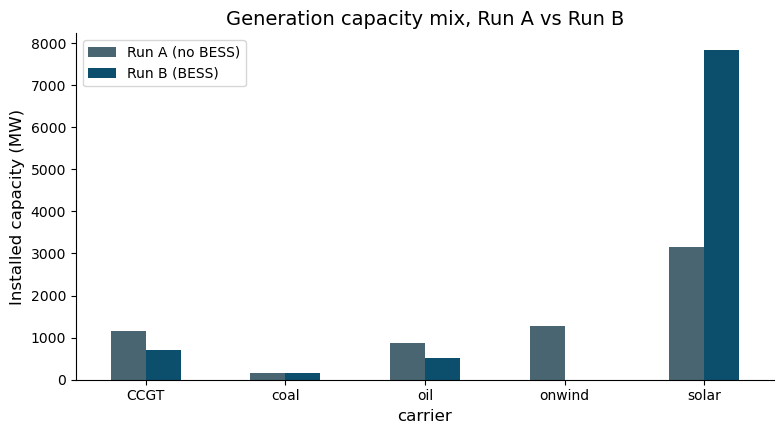

,Run A (no BESS),Run B (BESS)
carrier,,
CCGT,1169.425876,711.001321
coal,155.000131,155.000564
oil,861.288572,524.460981
onwind,1265.100702,0.050567
solar,3159.188079,7838.492882


In [27]:
def capacity_by_carrier(n):
    capacity = n.generators.p_nom_opt.where(n.generators.p_nom_extendable, n.generators.p_nom)
    return capacity.groupby(n.generators.carrier).sum().drop("load shedding", errors="ignore")

def generation_twh_by_carrier(n):
    w = n.snapshot_weightings.generators
    by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    return (by_carrier.mul(w, axis=0).sum() / 1e6).drop("load shedding", errors="ignore")

cap_a, cap_b = capacity_by_carrier(n_a), capacity_by_carrier(n_b)
carriers = sorted(set(cap_a.index) | set(cap_b.index))
cap_df = pd.DataFrame({"Run A (no BESS)": cap_a.reindex(carriers, fill_value=0),
                        "Run B (BESS)": cap_b.reindex(carriers, fill_value=0)})

fig, ax = plt.subplots(figsize=(8, 4.5))
cap_df.plot(kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("Installed capacity (MW)")
ax.set_title("Generation capacity mix, Run A vs Run B")
plt.setp(ax.get_xticklabels(), rotation=0)
savefig(fig, "capacity_mix")
plt.show()
cap_df


saved figures/generation_mix.png


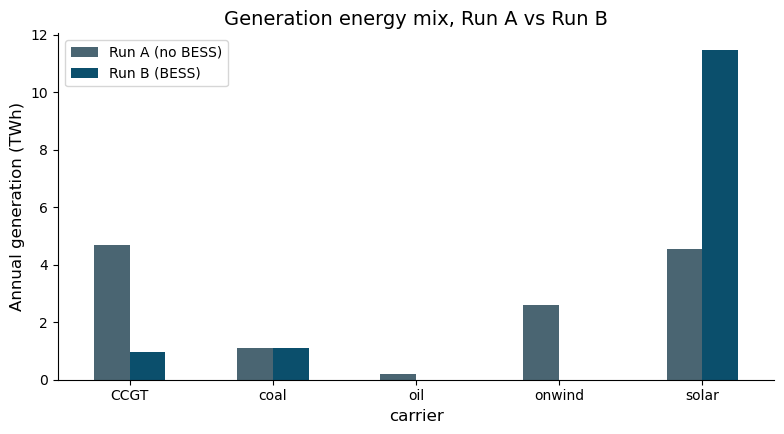

,Run A (no BESS),Run B (BESS)
carrier,,
CCGT,4.683294,0.956523
coal,1.091940,1.094909
oil,0.185551,0.000002
onwind,2.592776,0.000094
solar,4.555597,11.480824


In [28]:
gen_a, gen_b = generation_twh_by_carrier(n_a), generation_twh_by_carrier(n_b)
gen_df = pd.DataFrame({"Run A (no BESS)": gen_a.reindex(carriers, fill_value=0),
                        "Run B (BESS)": gen_b.reindex(carriers, fill_value=0)})

fig, ax = plt.subplots(figsize=(8, 4.5))
gen_df.plot(kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("Annual generation (TWh)")
ax.set_title("Generation energy mix, Run A vs Run B")
plt.setp(ax.get_xticklabels(), rotation=0)
savefig(fig, "generation_mix")
plt.show()
gen_df


## 9. Representative Week: How the Battery Actually Operates

A sample week (early March) showing hourly generation by carrier, demand, and (for Run B) net
battery power and state of charge. This is the mechanism behind the capacity/generation shifts
in Section 8: the battery soaks up midday solar surplus (SOC rises while solar output exceeds
demand, battery power goes negative = charging) and discharges it back in the evening/night
ramp (battery power positive = delivering to the grid), which is why so much more solar gets
built and used in Run B while CCGT/oil usage drops. Run A (no BESS) is plotted immediately
after for direct comparison -- notice how much more closely generation has to track demand
hour-by-hour without storage to smooth it out.

saved figures/representative_week_runB.png


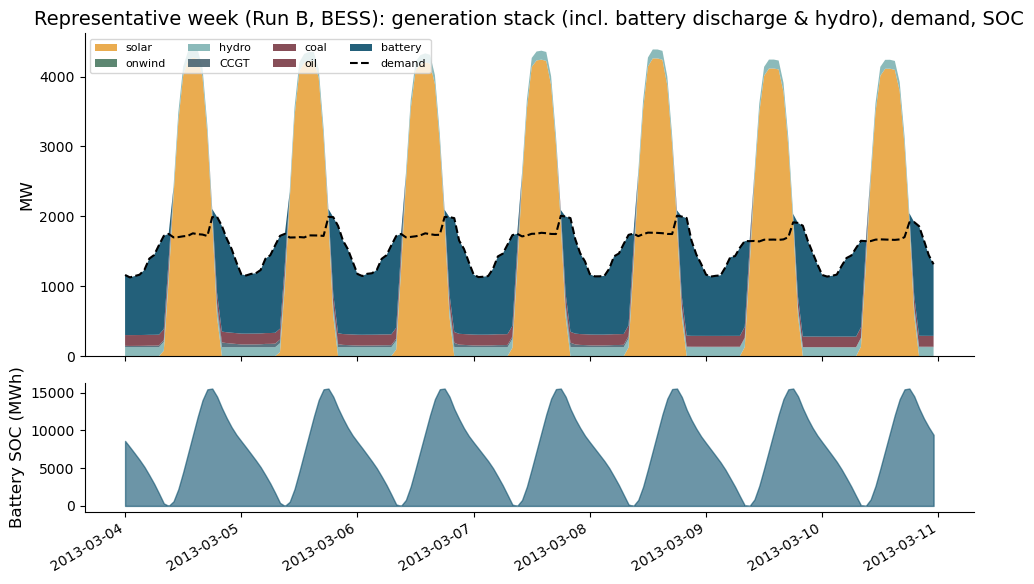

Max |demand - stack| gap: 2,641.1 MW (expected: 0 outside charging hours, equal to net charging power during them)


In [29]:
week = slice("2013-03-04", "2013-03-10")

def gen_stack(n):
    g = n.generators_t.p.T.groupby(n.generators.carrier).sum().T.loc[week]
    return g.drop(columns=["load shedding"], errors="ignore")

def storage_unit_discharge_by_carrier(n):
    '''StorageUnit is a separate PyPSA component from Generator (hydro's reservoir, and the 4
    named custom BESS projects, are both StorageUnits) -- n.generators_t.p never includes them.
    Clipped to discharge only, consistent with the generator stack showing production, not net flow.'''
    if len(n.storage_units) == 0:
        return pd.DataFrame(index=n.snapshots).loc[week]
    su = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T.loc[week]
    return su.clip(lower=0)

def battery_link_discharge_mw(n):
    '''Discharge side of the extendable Store-based battery fleet (via its Link chargers/dischargers).'''
    charger = [c for c in n.links.index if "battery charger" in c]
    if not charger:
        return pd.Series(0.0, index=n.snapshots).loc[week]
    discharger = [c for c in n.links.index if "battery discharger" in c]
    p0_charger = n.links_t.p0[charger].sum(axis=1).loc[week]
    p1_discharger = n.links_t.p1[discharger].sum(axis=1).loc[week]
    return (-p0_charger - p1_discharger).clip(lower=0)

gen_week = gen_stack(n_b)
su_week = storage_unit_discharge_by_carrier(n_b)  # 'hydro' StorageUnit + the 4 custom BESS 'battery' StorageUnit
soc_week = n_b.stores_t.e.loc[week].sum(axis=1)
demand_week = n_b.loads_t.p_set.sum(axis=1).loc[week]

gen_week["hydro"] = su_week.get("hydro", 0)
gen_week["battery"] = su_week.get("battery", 0) + battery_link_discharge_mw(n_b)  # custom BESS + extendable fleet, combined

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2.5, 1])
order = [c for c in ["solar", "onwind", "hydro", "CCGT", "coal", "oil", "battery"] if c in gen_week.columns]
colors = [color_for(c) for c in order]
ax1.stackplot(gen_week.index, [gen_week[c] for c in order], labels=order, colors=colors, alpha=0.9)
ax1.plot(demand_week.index, demand_week.values, color="black", linewidth=1.5, linestyle="--", label="demand")
ax1.set_ylabel("MW")
ax1.set_title("Representative week (Run B, BESS): generation stack (incl. battery discharge & hydro), demand, SOC")
ax1.legend(loc="upper left", ncol=4, fontsize=8)

ax2.fill_between(soc_week.index, soc_week.values, color=PALETTE["blue_teal"], alpha=0.6)
ax2.set_ylabel("Battery SOC (MWh)")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
savefig(fig, "representative_week_runB")
plt.show()

# Sanity check: the stack should match demand exactly whenever the battery isn't net-charging
# (charging hours legitimately show stack > demand -- that gap *is* the power going into storage).
gap = demand_week - gen_week[order].sum(axis=1)
print(f"Max |demand - stack| gap: {gap.abs().max():,.1f} MW (expected: 0 outside charging hours, "
      f"equal to net charging power during them)")


saved figures/representative_week_runA.png


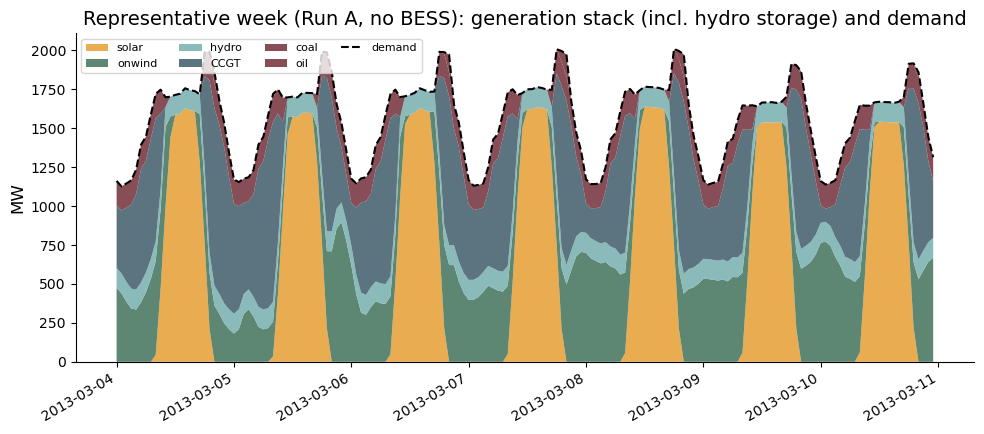

Max |demand - stack| gap: 5.31e-09 MW (should be ~0 -- Run A's hydro never net-charges this week)


In [30]:
gen_week_a = gen_stack(n_a)
su_week_a = storage_unit_discharge_by_carrier(n_a)  # 'hydro' StorageUnit -- not in n.generators_t.p
demand_week_a = n_a.loads_t.p_set.sum(axis=1).loc[week]
gen_week_a["hydro"] = su_week_a.get("hydro", 0)

order_a = [c for c in ["solar", "onwind", "hydro", "CCGT", "coal", "oil"] if c in gen_week_a.columns]
colors_a = [color_for(c) for c in order_a]

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.stackplot(gen_week_a.index, [gen_week_a[c] for c in order_a], labels=order_a, colors=colors_a, alpha=0.9)
ax1.plot(demand_week_a.index, demand_week_a.values, color="black", linewidth=1.5, linestyle="--", label="demand")
ax1.set_ylabel("MW")
ax1.set_title("Representative week (Run A, no BESS): generation stack (incl. hydro storage) and demand")
ax1.legend(loc="upper left", ncol=4, fontsize=8)
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")
savefig(fig, "representative_week_runA")
plt.show()

gap_a = demand_week_a - gen_week_a[order_a].sum(axis=1)
print(f"Max |demand - stack| gap: {gap_a.abs().max():.2e} MW (should be ~0 -- Run A's hydro never net-charges this week)")


## 10. System-Average Cost per MWh Served

The full system cost (Section 7's `total_a`/`total_b`, all assets) divided by total annual
demand -- a single blended €/MWh figure comparable to a system-wide LCOE, useful as one summary
number alongside the detailed breakdowns above.

saved figures/cost_per_mwh.png


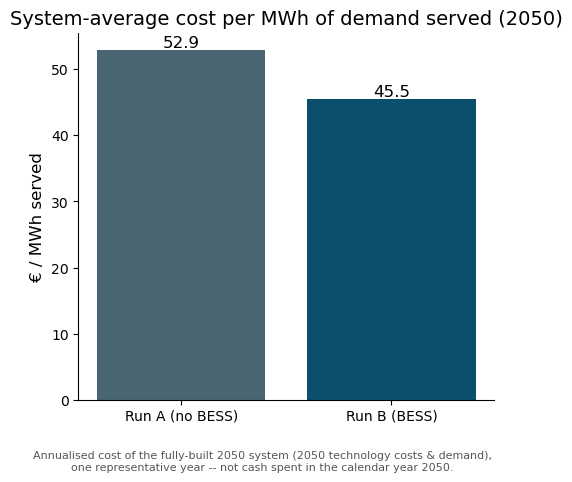

Demand: Run A = 14.23 TWh/yr, Run B = 14.23 TWh/yr


Run A (no BESS)    52.893545
Run B (BESS)       45.466522
dtype: float64

In [31]:
def annual_demand_mwh(n):
    w = n.snapshot_weightings.generators
    return (n.loads_t.p_set.sum(axis=1) * w).sum()

demand_a, demand_b = annual_demand_mwh(n_a), annual_demand_mwh(n_b)
per_mwh = pd.Series({
    "Run A (no BESS)": total_a / demand_a,
    "Run B (BESS)": total_b / demand_b,
})

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(per_mwh.index, per_mwh.values, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("€ / MWh served")
ax.set_title("System-average cost per MWh of demand served (2050)")
fig.text(0.5, -0.02,
          "Annualised cost of the fully-built 2050 system (2050 technology costs & demand),\n"
          "one representative year -- not cash spent in the calendar year 2050.",
          ha="center", va="top", fontsize=8, color="#555555")
for i, v in enumerate(per_mwh.values):
    ax.annotate(f"{v:.1f}", (i, v), ha="center", va="bottom")
savefig(fig, "cost_per_mwh")
plt.show()
print(f"Demand: Run A = {demand_a/1e6:.2f} TWh/yr, Run B = {demand_b/1e6:.2f} TWh/yr")
per_mwh


## 11. Renewable Curtailment

Curtailment = potential VRE generation (`p_max_pu × p_nom_opt`, what solar/onwind *could* have
produced given the weather and installed capacity) minus what was actually dispatched (`p`).
Only meaningful for solar/onwind -- thermal and storage carriers aren't "curtailed" in this
sense, they're simply not dispatched when uneconomical. Bars show absolute curtailed energy;
the percentage labels are the curtailment *rate* (curtailed / potential).

saved figures/curtailment.png


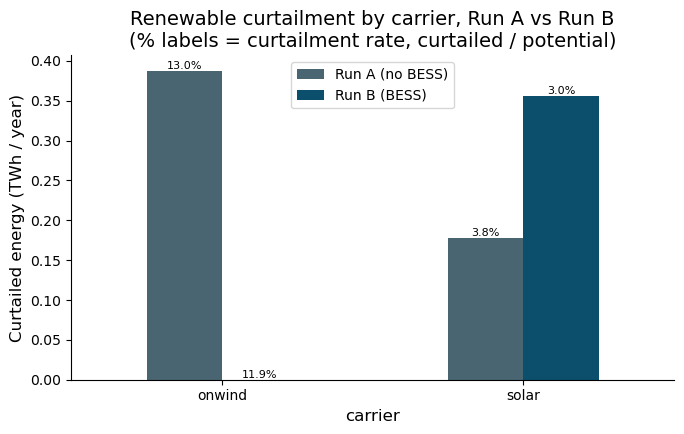

Curtailed energy (TWh/year):
          Run A (no BESS)  Run B (BESS)
carrier                               
onwind          0.387684      0.000013
solar           0.178177      0.355491

Available potential (TWh/year):
             Run A      Run B
carrier                     
onwind   2.980460   0.000107
solar    4.733774  11.836314

Curtailment rate (%):
          Run A (no BESS)  Run B (BESS)
carrier                               
onwind         13.007538     11.882458
solar           3.763948      3.003390


In [32]:
def curtailment_by_carrier(n):
    vre = n.generators[n.generators.carrier.isin(["solar", "onwind"])]
    w = n.snapshot_weightings.generators
    avail = n.generators_t.p_max_pu[vre.index].mul(vre.p_nom_opt, axis=1)
    actual = n.generators_t.p[vre.index]
    curtailed = (avail - actual).clip(lower=0)
    curtailed_twh = curtailed.mul(w, axis=0).T.groupby(vre.carrier).sum().T.sum() / 1e6
    avail_twh = avail.mul(w, axis=0).T.groupby(vre.carrier).sum().T.sum() / 1e6
    rate_pct = 100 * curtailed_twh / avail_twh
    return curtailed_twh, avail_twh, rate_pct

curt_a, avail_a, rate_a = curtailment_by_carrier(n_a)
curt_b, avail_b, rate_b = curtailment_by_carrier(n_b)
vre_carriers = sorted(set(curt_a.index) | set(curt_b.index))

curt_df = pd.DataFrame({"Run A (no BESS)": curt_a.reindex(vre_carriers, fill_value=0),
                         "Run B (BESS)": curt_b.reindex(vre_carriers, fill_value=0)})
rate_df = pd.DataFrame({"Run A (no BESS)": rate_a.reindex(vre_carriers, fill_value=0),
                         "Run B (BESS)": rate_b.reindex(vre_carriers, fill_value=0)})

fig, ax = plt.subplots(figsize=(7, 4.5))
curt_df.plot(kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("Curtailed energy (TWh / year)")
ax.set_title("Renewable curtailment by carrier, Run A vs Run B\n(% labels = curtailment rate, curtailed / potential)")
plt.setp(ax.get_xticklabels(), rotation=0)
for container, col in zip(ax.containers, curt_df.columns):
    for rect, carrier in zip(container, curt_df.index):
        rate = rate_df.loc[carrier, col]
        ax.annotate(f"{rate:.1f}%", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                    ha="center", va="bottom", fontsize=8)
savefig(fig, "curtailment")
plt.show()

print("Curtailed energy (TWh/year):\n", curt_df)
print("\nAvailable potential (TWh/year):\n", pd.DataFrame({"Run A": avail_a, "Run B": avail_b}))
print("\nCurtailment rate (%):\n", rate_df)
